# DATA MINING - Assignment 1
## Task 1a: Data Inspection and Reduction

**Dataset:** Instacart Online Grocery Orders  
**Goal:** Understand the structure of the dataset and reduce it to a manageable size for frequent pattern mining.



---
## 0. Import and configuration


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from apyori import apriori
from mlxtend.frequent_patterns import association_rules
import os

#creating paths for accessibility
path = r'C:\Users\MiniPC\Documents\Data mining\A1\datas'

AISLES_PATH = os.path.join(path, 'aisles.csv')
DEPARTMENTS_PATH    = os.path.join(path, 'departments.csv')
PRODUCTS_PATH       = os.path.join(path, 'products.csv')
ORDERS_PATH         = os.path.join(path, 'orders.csv')
ORDER_PRODUCTS_PATH = os.path.join(path, 'order_products.csv')


---
## 1. Loading tables


In [14]:
#load lookup table
aisles      = pd.read_csv(AISLES_PATH)
departments = pd.read_csv(DEPARTMENTS_PATH)
products    = pd.read_csv(PRODUCTS_PATH)

print("=== aisles.csv ===")
print(f"Shape: {aisles.shape}")
display(aisles.head(5))

print("\n=== departments.csv ===")
print(f"Shape: {departments.shape}")
display(departments.head(5))

print("\n=== products.csv ===")
print(f"Shape: {products.shape}")
display(products.head(5))

=== aisles.csv ===
Shape: (134, 2)


,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation



=== departments.csv ===
Shape: (21, 2)


,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol



=== products.csv ===
Shape: (49688, 4)


,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


---
## 2. Loading order.csv


In [15]:
# Load main orders table
orders = pd.read_csv(ORDERS_PATH)

print(f"Shape: {orders.shape}")
print(f"Columns: {list(orders.columns)}")
print(f"\nMissing values:")
print(orders.isnull().sum())
display(orders.head(8))

Shape: (3421083, 6)
Columns: ['order_id', 'user_id', 'order_number', 'order_dow', 'order_hour_of_day', 'days_since_prior_order']

Missing values:
order_id                       0
user_id                        0
order_number                   0
order_dow                      0
order_hour_of_day              0
days_since_prior_order    206209
dtype: int64


,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,1,2,8,NaN
1,2398795,1,2,3,7,15.0
2,473747,1,3,3,12,21.0
3,2254736,1,4,4,7,29.0
4,431534,1,5,4,15,28.0
5,3367565,1,6,2,7,19.0
6,550135,1,7,1,9,20.0
7,3108588,1,8,1,14,14.0


In [16]:
print(f"Unique users:  {orders['user_id'].nunique():,}")
print(f"Unique orders: {orders['order_id'].nunique():,}")
print(f"\nOrders per user:")
print(orders.groupby('user_id')['order_id'].count().describe())

Unique users:  206,209
Unique orders: 3,421,083

Orders per user:
count    206209.000000
mean         16.590367
std          16.654774
min           4.000000
25%           6.000000
50%          10.000000
75%          20.000000
max         100.000000
Name: order_id, dtype: float64


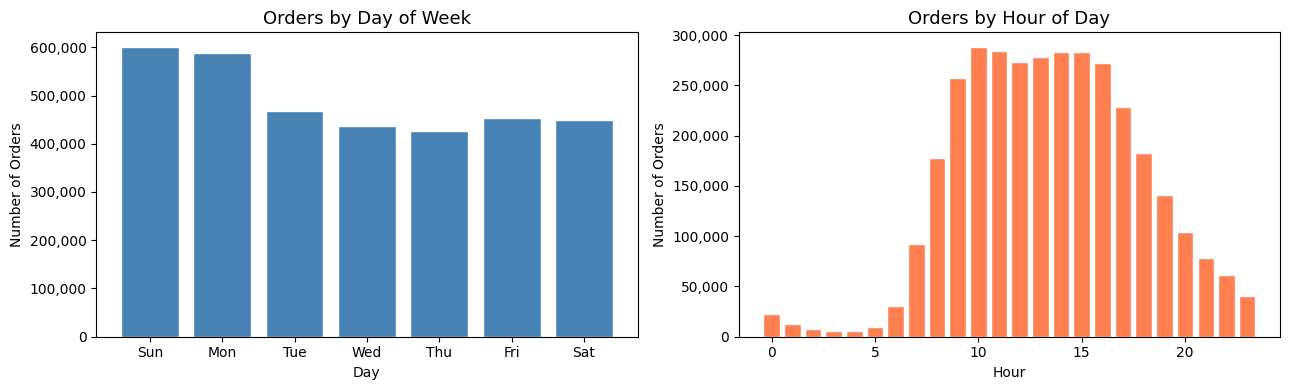

In [17]:
#plotting
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

day_labels = ['Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat']
dow_counts = orders['order_dow'].value_counts().sort_index()
axes[0].bar(day_labels, dow_counts.values, color='steelblue', edgecolor='white')
axes[0].set_title("Orders by Day of Week", fontsize=13)
axes[0].set_xlabel("Day")
axes[0].set_ylabel("Number of Orders")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

hour_counts = orders['order_hour_of_day'].value_counts().sort_index()
axes[1].bar(hour_counts.index, hour_counts.values, color='coral', edgecolor='white')
axes[1].set_title("Orders by Hour of Day", fontsize=13)
axes[1].set_xlabel("Hour")
axes[1].set_ylabel("Number of Orders")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

---
## 3. Loading order_product.csv

In [18]:
# Read only the first chunk 
op_sample = pd.read_csv(ORDER_PRODUCTS_PATH, nrows=10)
print(f"Columns: {list(op_sample.columns)}")
display(op_sample)

op = pd.read_csv(ORDER_PRODUCTS_PATH)
print(f"Lin amount in order_products : {len(op):,}")
print(f"Nombre de commandes uniques : {op['order_id'].nunique():,}")

file_size = os.path.getsize(ORDER_PRODUCTS_PATH) / (1024**3) # Taille en Go
print(f"File size on disk : {file_size:.2f} GB")

Columns: ['order_id', 'product_id', 'add_to_cart_order', 'reordered']


,order_id,product_id,add_to_cart_order,reordered
0,1,49302,1,1
1,1,11109,2,1
2,1,10246,3,0
3,1,49683,4,0
4,1,43633,5,1
5,1,13176,6,0
6,1,47209,7,0
7,1,22035,8,1
8,2,33120,1,1
9,2,28985,2,1


Lin amount in order_products : 33,819,106
Nombre de commandes uniques : 3,346,083
File size on disk : 0.59 GB


---
## 4. Data Reduction 

### Approach : Sampling over orders

Since our goal is to find pattern between product so which product are brought together, I decided to use Order as unit of analysis and sampling over them.
Then we arrange them into transactions.


In [19]:
#strategy = we sample by order id
RANDOM_SEED    = 42
SAMPLE_N_ORDERS = 150_000

sampled_orders = orders.sample(n=SAMPLE_N_ORDERS, random_state=RANDOM_SEED)
sampled_order_ids = set(sampled_orders['order_id'])

print(f"Sampled orders: {len(sampled_orders):,}")


Sampled orders: 150,000


## Task 1b: Constructing Transactions


In [20]:
# Filter the product
filtered_order_products = op[
    op["order_id"].isin(sampled_orders["order_id"])
]

# Format data into a list of transactions for Market Analysis (Apriori input)
transactions = (
    filtered_order_products
    .groupby("order_id")["product_id"]
    .apply(lambda x: [str(i) for i in x])
)
print(transactions.head())

order_id
33     [5699, 32740, 8592, 1446, 46313, 19970, 49390,...
47                   [16797, 39275, 43352, 46041, 29223]
107    [35535, 31577, 47783, 30391, 43394, 16953, 11513]
181    [20995, 35166, 8903, 38456, 24852, 7461, 14084...
193    [12409, 45946, 32028, 21291, 3873, 13176, 3592...
Name: product_id, dtype: object


---
## 5. View on the new datasets

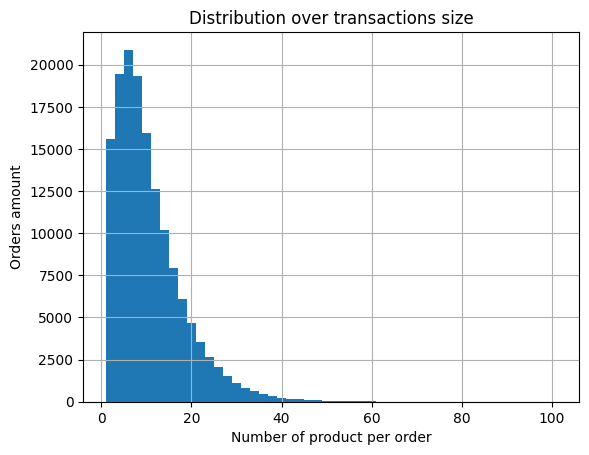

count    146776.000000
mean         10.119236
std           7.561763
min           1.000000
25%           5.000000
50%           8.000000
75%          14.000000
max         101.000000
dtype: float64


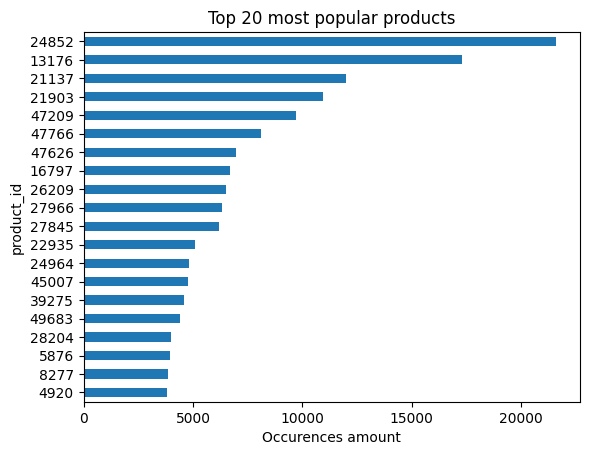

In [21]:
# Check transaction size
order_sizes = filtered_order_products.groupby("order_id").size()

plt.figure()
order_sizes.hist(bins=50)
plt.xlabel("Number of product per order")
plt.ylabel("Orders amount")
plt.title("Distribution over transactions size")
plt.show()

print(order_sizes.describe())

#------------------------------------------------------------------

# Identifying the Top N most frequent items to anticipate high-support rules
topN = 20
top_products = filtered_order_products["product_id"].value_counts().head(topN)

plt.figure()
top_products.sort_values().plot(kind="barh")
plt.xlabel("Occurences amount")
plt.ylabel("product_id")
plt.title(f"Top {topN} most popular products")
plt.show()

---
## 6. Save new csv

In [22]:
# Saving in CSV to be reused

output_path = r'C:\Users\MiniPC\Documents\Data mining\A1\sampled_datas'

filtered_order_products.to_csv(os.path.join(output_path, "order_products_sampled.csv"), index=False)
transactions.to_csv(os.path.join(output_path,"transactions_sampled.csv"), index=False)

# creating list of list & storing in json for Apriori (input)
transactions_list = transactions.tolist()

import json
with open(os.path.join(output_path, "transactions_sampled.json"), "w") as f:
    json.dump(transactions_list, f)

print(" Succesully saved")

 Succesully saved
